## Key Parameters to Adjust for Better SRGAN Results

If you get suboptimal results with the SRGAN implementation, here are the key parameters you can modify to improve performance:

### 1. Generator Architecture Parameters

- **RESIDUAL_BLOCKS** (default: 16): More blocks can capture more complex features but require more VRAM. Try values from **8-24**.
- **GENERATOR_FEATURES** (default: 64): More feature maps can represent more details but increase memory usage. Try **32, 48, 96, or 128**.
- **UPSAMPLING_LAYERS**: If working with larger scale factors, consider increasing the number of upsampling layers.

### 2. Discriminator Parameters

- **Discriminator Depth**: The current implementation has 8 convolutional layers. For more stable training, try adding or removing layers.
- **Feature Map Progression**: The feature maps double every few layers (64→128→256→512). Try a different progression like (32→64→128→256) for a lighter model.

### 3. Data Processing Parameters

- **IMAGE_SIZE** (default: 128): Larger sizes preserve more detail but require significantly more memory for GAN training. Try **96, 160, or 192**.
- **DOWNSCALE_FACTOR** (default: 4): Controls degradation level. Try **2** for less degradation or **8** for more challenging super-resolution.

### 4. GAN Training Parameters

- **GENERATOR_LR** (default: 0.0001): GANs are sensitive to learning rates. Try **0.00005 or 0.0002**.
- **DISCRIMINATOR_LR** (default: 0.0001): Often needs separate tuning from generator. Try **0.00005-0.0002**.
- **BATCH_SIZE** (default: 8): Smaller batch sizes often work better for GANs. Try **4, 16, or 32** depending on available memory.
- **EPOCHS** (default: 50): GANs may need more training time. Try **75-200** epochs, monitoring image quality not just metrics.

### 5. Loss Balancing Parameters

- **CONTENT_LOSS_WEIGHT** (default: 1.0): Controls importance of pixel accuracy. Try **0.5-2.0**.
- **ADVERSARIAL_LOSS_WEIGHT** (default: 0.001): Controls generator's focus on fooling discriminator. Try **0.0005-0.005**.
- **PERCEPTUAL_LOSS_WEIGHT** (default: 0.006): Controls VGG feature matching. Try **0.002-0.01**.

### 6. Training Stability Techniques

- **Label Smoothing**: Already implemented with random noise (0.1). Try **0.05-0.2** for different levels of smoothing.
- **Gradient Clipping**: Add to prevent gradient explosions:

```python
torch.nn.utils.clip_grad_norm_(generator.parameters(), max_norm=1.0)
torch.nn.utils.clip_grad_norm_(discriminator.parameters(), max_norm=1.0)
```

- **Two Time-Scale Update Rule (TTUR)**: Use different learning rates for generator and discriminator:

```python
# Example: slower generator, faster discriminator
optimizer_G = optim.Adam(generator.parameters(), lr=0.0001, betas=(0.9, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0004, betas=(0.9, 0.999))
```

### 7. Feature Extractor Options

- **VGG_FEATURE_LAYER** (default: 'relu5_4'): Try different VGG layers like **'relu3_3'** (earlier features) or **'relu4_4'** (mid-level features).
- **Alternative Backbones**: Instead of VGG, experiment with ResNet features:

```python
# Using ResNet instead of VGG
feature_extractor = models.resnet50(pretrained=True)
feature_extractor = nn.Sequential(*list(feature_extractor.children())[:7])  # Take features before final pooling
```

### 8. Data Augmentation for GANs

```python
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(5),  # GANs prefer subtle augmentations
    transforms.ColorJitter(brightness=0.05),  # For variation in medical image brightness
])
```

### 9. Advanced GAN Techniques

- **Spectral Normalization**: Stabilizes discriminator training:

```python
from torch.nn.utils import spectral_norm

# Apply to discriminator convolutions
self.conv1 = spectral_norm(nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1))
```

- **Relativistic GAN**: Makes discriminator predict relative realness:

```python
# In adversarial loss calculation
real_logits = discriminator(hr_images)
fake_logits = discriminator(fake_images)
rel_real_logits = real_logits - fake_logits.mean()
rel_fake_logits = fake_logits - real_logits.mean()
```

### Debugging Strategies for GANs

- **Mode Collapse Check**: Regularly save and inspect generated images to ensure diversity.
- **Frequency Domain Analysis**: Compute FFT of generated images to check if high-frequency details are being captured.
- **Progressive GAN Training**: Start with easier tasks (2x upscaling) before more difficult ones (4x upscaling).
- **Separate Pretraining**: First train generator with only content loss, then fine-tune with GAN loss.
- **Track FID Score**: If possible, implement Fréchet Inception Distance to quantitatively measure image quality.
- **Manual Image Inspection**: PSNR/SSIM don't always correlate with perceptual quality in GANs—regularly inspect outputs visually.
- **One-sided Label Smoothing**: Only smooth the real labels, not the fake ones.

### GAN-Specific Troubleshooting

- **Discriminator too strong**: If loss is near zero, reduce discriminator learning rate or update it less frequently.
- **Checkerboard artifacts**: Ensure proper initialization in upsampling layers or try different upsampling methods.
- **Blurry results**: Increase adversarial loss weight or try different feature layers in perceptual loss.
- **Training instability**: Implement gradient penalty or one-sided label smoothing.
- **Poor convergence**: Consider a curriculum learning approach, starting with easier examples.

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from sklearn.model_selection import train_test_split
import glob
import cv2
from tqdm import tqdm
import pandas as pd
import gc

# Reproducibility Setup
def set_seed(seed=42):
    """
    Set random seeds for reproducibility across libraries
    """
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    print(f"[DEBUG] Random seed set to {seed}")

set_seed()

class Config:
    """
    Centralized configuration class for easy parameter management
    """
    # Data Parameters
    IMAGE_SIZE = 128  # Keep smaller to save memory
    DATASET_PATH = "/kaggle/input/chest-x-ray-dataset/chest_xray"
    DOWNSCALE_FACTOR = 4

    # Training Parameters
    BATCH_SIZE = 8  # Smaller batch size for GAN training stability
    EPOCHS = 21 #(Default 50)
    GENERATOR_LR = 0.0001
    DISCRIMINATOR_LR = 0.0001
    ADAM_BETA1 = 0.9
    ADAM_BETA2 = 0.999
    
    # Loss Weights
    CONTENT_LOSS_WEIGHT = 1.0
    ADVERSARIAL_LOSS_WEIGHT = 0.001
    
    # VGG Feature Extractor Parameters
    VGG_FEATURE_LAYER = 'relu5_4'
    
    # Model Architecture Parameters
    GENERATOR_FEATURES = 64   # Number of feature maps in generator
    RESIDUAL_BLOCKS = 16      # Number of residual blocks in generator
    
    # Memory Management
    MIXED_PRECISION = True    # Use mixed precision training
    
    # Hardware
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Debug
    DEBUG_MODE = True
    VERBOSE_LEVEL = 1

    @classmethod
    def display(cls):
        """
        Display all configuration parameters
        """
        print("Current Configuration:")
        for key, value in vars(cls).items():
            if not key.startswith('__') and not callable(value):
                print(f"{key}: {value}")

[DEBUG] Random seed set to 42


In [2]:
# Debugging function
def debug_log(message, level=1):
    """
    Centralized logging function for easier debugging
    """
    if Config.DEBUG_MODE and level <= Config.VERBOSE_LEVEL:
        print(f"[DEBUG] {message}")

## Define the Generator (SRResNet)

In [3]:
class ResidualBlock(nn.Module):
    """
    Residual block used in the generator
    """
    def __init__(self, channels):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(channels)
        self.relu = nn.PReLU()  # Parametric ReLU used in SRGAN
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(channels)

    def forward(self, x):
        residual = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += residual  # Skip connection
        return out


class UpsampleBlock(nn.Module):
    """
    Upsampling block for the generator using pixel shuffle
    """
    def __init__(self, in_channels, scale_factor):
        super(UpsampleBlock, self).__init__()
        self.conv = nn.Conv2d(in_channels, in_channels * (scale_factor ** 2), kernel_size=3, padding=1)
        self.pixel_shuffle = nn.PixelShuffle(scale_factor)
        self.relu = nn.PReLU()

    def forward(self, x):
        x = self.conv(x)
        x = self.pixel_shuffle(x)
        x = self.relu(x)
        return x


class Generator(nn.Module):
    """
    Generator network (SRResNet architecture)
    """
    def __init__(self, scale_factor=Config.DOWNSCALE_FACTOR, num_residual_blocks=Config.RESIDUAL_BLOCKS):
        super(Generator, self).__init__()
        
        # First layer
        self.conv1 = nn.Conv2d(1, Config.GENERATOR_FEATURES, kernel_size=9, padding=4)
        self.relu = nn.PReLU()
        
        # Residual blocks
        res_blocks = []
        for _ in range(num_residual_blocks):
            res_blocks.append(ResidualBlock(Config.GENERATOR_FEATURES))
        self.res_blocks = nn.Sequential(*res_blocks)
        
        # Post-residual block
        self.conv2 = nn.Conv2d(Config.GENERATOR_FEATURES, Config.GENERATOR_FEATURES, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(Config.GENERATOR_FEATURES)
        
        # Upsampling layers (in SRGAN, typically uses PixelShuffle)
        upsample_layers = []
        
        # We need to calculate how many upsampling blocks we need
        upsample_factor = scale_factor
        num_upsample_blocks = 0
        while upsample_factor > 1:
            if upsample_factor % 2 == 0:
                num_upsample_blocks += 1
                upsample_factor = upsample_factor // 2
            else:
                raise ValueError(f"Scale factor {scale_factor} must be a power of 2")
        
        # Add the required number of upsampling blocks
        for _ in range(num_upsample_blocks):
            upsample_layers.append(UpsampleBlock(Config.GENERATOR_FEATURES, scale_factor=2))
        
        self.upsampling = nn.Sequential(*upsample_layers)
        
        # Final output layer
        self.conv3 = nn.Conv2d(Config.GENERATOR_FEATURES, 1, kernel_size=9, padding=4)
        self.tanh = nn.Tanh()  # Output normalized to [-1, 1]
        
    def forward(self, x):
        # x is the low-resolution input
        # First, we'll directly interpolate the input to the target size
        # This is different from standard SRGAN but helps with our specific task
        
        # First layer
        out1 = self.relu(self.conv1(x))
        
        # Residual blocks
        out2 = self.res_blocks(out1)
        
        # Post-residual block
        out3 = self.bn2(self.conv2(out2))
        
        # Skip connection
        out3 = out3 + out1
        
        # Since we're not changing resolution in our case (input is already upsampled), 
        # we'll skip the upsampling blocks for now
        # out4 = self.upsampling(out3)
        
        # Final output layer
        out = self.tanh(self.conv3(out3))
        
        # Return output scaled to [0, 1] as expected by our dataset
        return (out + 1) / 2

## Define the Discriminator

In [4]:
class DiscriminatorBlock(nn.Module):
    """
    Convolutional block used in the discriminator
    """
    def __init__(self, in_channels, out_channels, stride=1, batch_norm=True):
        super(DiscriminatorBlock, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.batch_norm = nn.BatchNorm2d(out_channels) if batch_norm else None
        self.activation = nn.LeakyReLU(0.2, inplace=True)
        
    def forward(self, x):
        x = self.conv(x)
        if self.batch_norm:
            x = self.batch_norm(x)
        x = self.activation(x)
        return x


class Discriminator(nn.Module):
    """
    Discriminator network without sigmoid activation at the end
    """
    def __init__(self):
        super(Discriminator, self).__init__()
        
        # Define discriminator network structure
        self.features = nn.Sequential(
            # First layer, no batch norm
            DiscriminatorBlock(1, 64, stride=1, batch_norm=False),
            
            # Increasing number of features with stride 2 to reduce spatial dimensions
            DiscriminatorBlock(64, 64, stride=2),
            DiscriminatorBlock(64, 128, stride=1),
            DiscriminatorBlock(128, 128, stride=2),
            DiscriminatorBlock(128, 256, stride=1),
            DiscriminatorBlock(256, 256, stride=2),
            DiscriminatorBlock(256, 512, stride=1),
            DiscriminatorBlock(512, 512, stride=2),
        )
        
        # Flatten and add fully connected layers
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),  # Global average pooling
            nn.Flatten(),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(1024, 1)
            # Removed sigmoid activation
        )
        
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

## Feature Extractor (VGG) for perceptual loss

In [5]:
class FeatureExtractor(nn.Module):
    """
    Extracts features from a pretrained VGG19 model for perceptual loss
    """
    def __init__(self):
        super(FeatureExtractor, self).__init__()
        vgg19 = models.vgg19(pretrained=True)
        
        # We want to extract features from relu5_4 (before MaxPool5)
        self.features = nn.Sequential(*list(vgg19.features.children())[:35])
        
        # Freeze parameters
        for param in self.parameters():
            param.requires_grad = False
            
        # Move to the same device as the model
        self.features.to(Config.DEVICE)
        
    def forward(self, x):
        # Convert grayscale to RGB by repeating the channel 3 times
        if x.size(1) == 1:
            x = x.repeat(1, 3, 1, 1)
        
        # Normalize input to match VGG19 expected range
        x = (x - 0.5) * 2.0  # Scale from [0,1] to [-1,1]
        
        return self.features(x)

## Custom dataset class

In [6]:
class CXRDataset(Dataset):
    """
    Custom Dataset for Chest X-Ray Images
    """
    def __init__(self, lr_images, hr_images, transform=None):
        self.lr_images = lr_images
        self.hr_images = hr_images
        self.transform = transform
        
        debug_log(f"Dataset initialized with {len(lr_images)} image pairs", level=1)
    
    def __len__(self):
        return len(self.lr_images)
    
    def __getitem__(self, idx):
        lr_image = self.lr_images[idx]
        hr_image = self.hr_images[idx]
        
        # Convert to PyTorch tensors
        lr_tensor = torch.from_numpy(lr_image).float()
        hr_tensor = torch.from_numpy(hr_image).float()
        
        # Ensure [C, H, W] format for PyTorch
        lr_tensor = lr_tensor.permute(2, 0, 1)
        hr_tensor = hr_tensor.permute(2, 0, 1)
        
        if self.transform:
            lr_tensor = self.transform(lr_tensor)
            hr_tensor = self.transform(hr_tensor)
        
        return lr_tensor, hr_tensor

In [7]:
def prepare_data(dataset_path, limit_per_class=100, downscale_factor=Config.DOWNSCALE_FACTOR):
    """
    Prepare training and validation data for super-resolution
    """
    debug_log("Starting data preparation...", level=1)
    
    hr_images = []
    categories = ['NORMAL', 'PNEUMONIA']
    
    # Collect images from training directory
    for category in categories:
        # Support both .jpeg and .jpg extensions
        image_paths = (
            glob.glob(os.path.join(dataset_path, 'train', category, '*.jpeg')) +
            glob.glob(os.path.join(dataset_path, 'train', category, '*.jpg'))
        )
        
        debug_log(f"Found {len(image_paths)} {category} images", level=1)
        
        # Process a limited number of images to save memory
        for img_path in tqdm(image_paths[:limit_per_class], desc=f"Processing {category} images"):
            try:
                # Load image in grayscale
                img = cv2.imread(img_path, 0)  # 0 for grayscale
                
                if img is not None:
                    # Resize image to target size
                    img = cv2.resize(img, (Config.IMAGE_SIZE, Config.IMAGE_SIZE))
                    
                    # Normalize to [0, 1]
                    img = img.astype(np.float32) / 255.0
                    
                    hr_images.append(img)
            except Exception as e:
                debug_log(f"Error processing {img_path}: {e}", level=2)
    
    hr_images = np.array(hr_images)
    debug_log(f"Total HR images: {hr_images.shape}", level=1)
    
    # Create low-resolution images
    lr_images = []
    batch_size = 100  # Process in smaller batches to save memory
    
    for i in range(0, len(hr_images), batch_size):
        batch = hr_images[i:i+batch_size]
        lr_batch = []
        
        for img in tqdm(batch, desc=f"Creating low-resolution images (batch {i//batch_size + 1})"):
            # Downsample
            low_res = cv2.resize(img, (Config.IMAGE_SIZE // downscale_factor, Config.IMAGE_SIZE // downscale_factor))
            # Upsample back to original size
            low_res = cv2.resize(low_res, (Config.IMAGE_SIZE, Config.IMAGE_SIZE))
            lr_batch.append(low_res)
        
        lr_images.extend(lr_batch)
        
        # Force garbage collection
        del batch, lr_batch
        gc.collect()
    
    lr_images = np.array(lr_images)
    
    # Reshape for the model (add channel dimension)
    hr_images = hr_images.reshape(-1, Config.IMAGE_SIZE, Config.IMAGE_SIZE, 1)
    lr_images = lr_images.reshape(-1, Config.IMAGE_SIZE, Config.IMAGE_SIZE, 1)
    
    # Split into training and validation sets
    X_train, X_val, y_train, y_val = train_test_split(
        lr_images, hr_images, test_size=0.2, random_state=42
    )
    
    # Create PyTorch datasets
    train_dataset = CXRDataset(X_train, y_train)
    val_dataset = CXRDataset(X_val, y_val)
    
    # Create data loaders
    train_loader = DataLoader(
        train_dataset, 
        batch_size=Config.BATCH_SIZE, 
        shuffle=True, 
        num_workers=2,  # Reduced to save memory
        pin_memory=True
    )
    val_loader = DataLoader(
        val_dataset, 
        batch_size=Config.BATCH_SIZE, 
        shuffle=False, 
        num_workers=2,  # Reduced to save memory
        pin_memory=True
    )
    
    debug_log(f"Train loader: {len(train_loader)} batches", level=1)
    debug_log(f"Validation loader: {len(val_loader)} batches", level=1)
    
    return train_loader, val_loader

In [8]:
def load_test_data(dataset_path, limit_per_class=20, downscale_factor=Config.DOWNSCALE_FACTOR):
    """
    Load and prepare test data for evaluation
    """
    debug_log("Loading test data...", level=1)
    
    test_hr_images = []
    test_lr_images = []
    categories = ['NORMAL', 'PNEUMONIA']
    
    for category in categories:
        # Support both .jpeg and .jpg extensions
        image_paths = (
            glob.glob(os.path.join(dataset_path, 'test', category, '*.jpeg')) +
            glob.glob(os.path.join(dataset_path, 'test', category, '*.jpg'))
        )
        
        debug_log(f"Found {len(image_paths)} {category} test images", level=1)
        
        for img_path in tqdm(image_paths[:limit_per_class], desc=f"Processing {category} test images"):
            try:
                # Load image in grayscale
                img = cv2.imread(img_path, 0)
                
                if img is not None:
                    # Resize image to target size
                    img = cv2.resize(img, (Config.IMAGE_SIZE, Config.IMAGE_SIZE))
                    
                    # Normalize to [0, 1]
                    img = img.astype(np.float32) / 255.0
                    
                    # Create low resolution version
                    low_res = cv2.resize(img, (Config.IMAGE_SIZE // downscale_factor, Config.IMAGE_SIZE // downscale_factor))
                    low_res = cv2.resize(low_res, (Config.IMAGE_SIZE, Config.IMAGE_SIZE))
                    
                    test_hr_images.append(img)
                    test_lr_images.append(low_res)
            except Exception as e:
                debug_log(f"Error processing test image {img_path}: {e}", level=2)
    
    # Reshape for the model
    test_hr_images = np.array(test_hr_images).reshape(-1, Config.IMAGE_SIZE, Config.IMAGE_SIZE, 1)
    test_lr_images = np.array(test_lr_images).reshape(-1, Config.IMAGE_SIZE, Config.IMAGE_SIZE, 1)
    
    # Create PyTorch dataset
    test_dataset = CXRDataset(test_lr_images, test_hr_images)
    
    # Create data loader
    test_loader = DataLoader(
        test_dataset, 
        batch_size=Config.BATCH_SIZE, 
        shuffle=False, 
        num_workers=2,
        pin_memory=True
    )
    
    debug_log(f"Test loader: {len(test_loader)} batches", level=1)
    
    return test_loader, test_hr_images, test_lr_images

In [9]:
def train_gan(generator, discriminator, feature_extractor, train_loader, val_loader, num_epochs=Config.EPOCHS):
    """
    Train the SRGAN model
    """
    # Initialize optimizers
    optimizer_G = optim.Adam(generator.parameters(), lr=Config.GENERATOR_LR, betas=(Config.ADAM_BETA1, Config.ADAM_BETA2))
    optimizer_D = optim.Adam(discriminator.parameters(), lr=Config.DISCRIMINATOR_LR, betas=(Config.ADAM_BETA1, Config.ADAM_BETA2))
    
    # Loss functions
    content_criterion = nn.MSELoss()
    adversarial_criterion = nn.BCEWithLogitsLoss()
    
    # Setup for mixed precision training
    scaler_G = torch.amp.GradScaler("cuda") if Config.MIXED_PRECISION else None
    scaler_D = torch.amp.GradScaler("cuda") if Config.MIXED_PRECISION else None
    
    # Training history
    g_losses = []
    d_losses = []
    val_psnrs = []
    val_ssims = []
    
    # Labels for real and fake
    real_label = 1.0
    fake_label = 0.0
    
    for epoch in range(num_epochs):
        # Training phase
        generator.train()
        discriminator.train()
        
        # Track losses for this epoch
        epoch_g_loss = 0.0
        epoch_d_loss = 0.0
        
        # Progress bar for training
        train_progress = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", unit="batch")
        
        for lr_images, hr_images in train_progress:
            batch_size = lr_images.size(0)
            
            # Move data to device
            lr_images = lr_images.to(Config.DEVICE)
            hr_images = hr_images.to(Config.DEVICE)
            
            ############################
            # Train Discriminator
            ############################
            optimizer_D.zero_grad()
            
            # Mixed precision training for discriminator
            if Config.MIXED_PRECISION:
                with torch.amp.autocast("cuda"):
                    # Generate fake images
                    fake_images = generator(lr_images)
                    
                    # Real discriminator output
                    real_output = discriminator(hr_images)
                    # Fake discriminator output
                    fake_output = discriminator(fake_images.detach())  # Detach to not train generator
                    
                    # Create labels
                    real_labels = torch.full((batch_size, 1), real_label, dtype=torch.float, device=Config.DEVICE)
                    fake_labels = torch.full((batch_size, 1), fake_label, dtype=torch.float, device=Config.DEVICE)
                    
                    # Add noise to labels for better stability
                    real_labels = real_labels - 0.1 * torch.rand(real_labels.shape, device=Config.DEVICE)
                    fake_labels = fake_labels + 0.1 * torch.rand(fake_labels.shape, device=Config.DEVICE)
                    
                    # Calculate loss for real and fake images
                    d_loss_real = adversarial_criterion(real_output, real_labels)
                    d_loss_fake = adversarial_criterion(fake_output, fake_labels)
                    
                    # Total discriminator loss
                    d_loss = d_loss_real + d_loss_fake
                
                # Backward pass with scaled gradients
                scaler_D.scale(d_loss).backward()
                scaler_D.step(optimizer_D)
                scaler_D.update()
            else:
                # Generate fake images
                fake_images = generator(lr_images)
                
                # Real discriminator output
                real_output = discriminator(hr_images)
                # Fake discriminator output
                fake_output = discriminator(fake_images.detach())  # Detach to not train generator
                
                # Create labels
                real_labels = torch.full((batch_size, 1), real_label, dtype=torch.float, device=Config.DEVICE)
                fake_labels = torch.full((batch_size, 1), fake_label, dtype=torch.float, device=Config.DEVICE)
                
                # Add noise to labels for better stability
                real_labels = real_labels - 0.1 * torch.rand(real_labels.shape, device=Config.DEVICE)
                fake_labels = fake_labels + 0.1 * torch.rand(fake_labels.shape, device=Config.DEVICE)
                
                # Calculate loss for real and fake images
                d_loss_real = adversarial_criterion(real_output, real_labels)
                d_loss_fake = adversarial_criterion(fake_output, fake_labels)
                
                # Total discriminator loss
                d_loss = d_loss_real + d_loss_fake
                
                # Backward pass
                d_loss.backward()
                optimizer_D.step()
            
            ############################
            # Train Generator
            ############################
            optimizer_G.zero_grad()
            
            # Mixed precision training for generator
            if Config.MIXED_PRECISION:
                with torch.amp.autocast("cuda"):
                    # Generate fake images again
                    fake_images = generator(lr_images)
                    
                    # Get discriminator output for fake images
                    fake_output = discriminator(fake_images)
                    
                    # Create labels for generator (we want discriminator to think these are real)
                    gen_labels = torch.full((batch_size, 1), real_label, dtype=torch.float, device=Config.DEVICE)
                    
                    # Content loss (pixel-wise)
                    content_loss = content_criterion(fake_images, hr_images)
                    
                    # Perceptual loss (feature-wise)
                    if feature_extractor is not None:
                        fake_features = feature_extractor(fake_images)
                        real_features = feature_extractor(hr_images)
                        perceptual_loss = content_criterion(fake_features, real_features)
                    else:
                        perceptual_loss = 0.0
                    
                    # Adversarial loss
                    adversarial_loss = adversarial_criterion(fake_output, gen_labels)
                    
                    # Total generator loss
                    g_loss = content_loss + Config.ADVERSARIAL_LOSS_WEIGHT * adversarial_loss
                    if feature_extractor is not None:
                        g_loss += 0.006 * perceptual_loss  # VGG loss weight from paper
                
                # Backward pass with scaled gradients
                scaler_G.scale(g_loss).backward()
                scaler_G.step(optimizer_G)
                scaler_G.update()
            else:
                # Generate fake images again
                fake_images = generator(lr_images)
                
                # Get discriminator output for fake images
                fake_output = discriminator(fake_images)
                
                # Create labels for generator (we want discriminator to think these are real)
                gen_labels = torch.full((batch_size, 1), real_label, dtype=torch.float, device=Config.DEVICE)
                
                # Content loss (pixel-wise)
                content_loss = content_criterion(fake_images, hr_images)
                
                # Perceptual loss (feature-wise)
                if feature_extractor is not None:
                    fake_features = feature_extractor(fake_images)
                    real_features = feature_extractor(hr_images)
                    perceptual_loss = content_criterion(fake_features, real_features)
                else:
                    perceptual_loss = 0.0
                
                # Adversarial loss
                adversarial_loss = adversarial_criterion(fake_output, gen_labels)
                
                # Total generator loss
                g_loss = content_loss + Config.ADVERSARIAL_LOSS_WEIGHT * adversarial_loss
                if feature_extractor is not None:
                    g_loss += 0.006 * perceptual_loss  # VGG loss weight from paper
                
                # Backward pass
                g_loss.backward()
                optimizer_G.step()
            
            # Update progress bar and track losses
            epoch_g_loss += g_loss.item()
            epoch_d_loss += d_loss.item()
            train_progress.set_postfix(G_loss=g_loss.item(), D_loss=d_loss.item())
            
            # Clean up CUDA memory
            del lr_images, hr_images, fake_images
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
        
        # Compute average training losses for epoch
        avg_g_loss = epoch_g_loss / len(train_loader)
        avg_d_loss = epoch_d_loss / len(train_loader)
        g_losses.append(avg_g_loss)
        d_losses.append(avg_d_loss)
        
        # Validation phase
        generator.eval()
        epoch_val_psnr = 0.0
        epoch_val_ssim = 0.0
        
        with torch.no_grad():
            for lr_images, hr_images in val_loader:
                lr_images = lr_images.to(Config.DEVICE)
                hr_images = hr_images.to(Config.DEVICE)
                
                # Generate super-resolved images
                sr_images = generator(lr_images)
                
                # Calculate PSNR and SSIM
                for i in range(sr_images.size(0)):
                    # Convert to numpy for PSNR and SSIM calculation
                    sr_img = sr_images[i].cpu().numpy().squeeze()
                    hr_img = hr_images[i].cpu().numpy().squeeze()
                    
                    # Calculate PSNR
                    val_psnr = psnr(hr_img, sr_img, data_range=1.0)
                    epoch_val_psnr += val_psnr
                    
                    # Calculate SSIM
                    val_ssim = ssim(hr_img, sr_img, data_range=1.0)
                    epoch_val_ssim += val_ssim
                
                # Clean up memory
                del lr_images, hr_images, sr_images
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()
        
        # Compute average validation metrics for epoch
        avg_val_psnr = epoch_val_psnr / (len(val_loader) * Config.BATCH_SIZE)
        avg_val_ssim = epoch_val_ssim / (len(val_loader) * Config.BATCH_SIZE)
        val_psnrs.append(avg_val_psnr)
        val_ssims.append(avg_val_ssim)
        
        # Log training progress
        debug_log(
            f"Epoch {epoch+1}/{num_epochs}: G_Loss = {avg_g_loss:.4f}, D_Loss = {avg_d_loss:.4f}, "
            f"Val PSNR = {avg_val_psnr:.2f} dB, Val SSIM = {avg_val_ssim:.4f}"
        )
        
        # Save model checkpoint
        torch.save({
            'epoch': epoch,
            'generator_state_dict': generator.state_dict(),
            'discriminator_state_dict': discriminator.state_dict(),
            'g_optimizer_state_dict': optimizer_G.state_dict(),
            'd_optimizer_state_dict': optimizer_D.state_dict(),
            'g_loss': avg_g_loss,
            'd_loss': avg_d_loss,
            'val_psnr': avg_val_psnr,
            'val_ssim': avg_val_ssim,
        }, f'srgan_checkpoint_epoch_{epoch+1}.pth')
        
                    # Clean up memory at end of epoch
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            gc.collect()
    
    return g_losses, d_losses, val_psnrs, val_ssims

In [10]:
def plot_gan_losses(g_losses, d_losses, val_psnrs, val_ssims):
    """
    Plot GAN training losses and validation metrics
    """
    # Create figure with 2x2 subplots
    fig, axs = plt.subplots(2, 2, figsize=(15, 10))
    
    # Plot generator and discriminator losses
    axs[0, 0].plot(g_losses, label='Generator Loss')
    axs[0, 0].set_title('Generator Loss')
    axs[0, 0].set_xlabel('Epoch')
    axs[0, 0].set_ylabel('Loss')
    axs[0, 0].grid(True)
    
    axs[0, 1].plot(d_losses, label='Discriminator Loss')
    axs[0, 1].set_title('Discriminator Loss')
    axs[0, 1].set_xlabel('Epoch')
    axs[0, 1].set_ylabel('Loss')
    axs[0, 1].grid(True)
    
    # Plot PSNR and SSIM
    axs[1, 0].plot(val_psnrs, label='PSNR')
    axs[1, 0].set_title('Validation PSNR')
    axs[1, 0].set_xlabel('Epoch')
    axs[1, 0].set_ylabel('PSNR (dB)')
    axs[1, 0].grid(True)
    
    axs[1, 1].plot(val_ssims, label='SSIM')
    axs[1, 1].set_title('Validation SSIM')
    axs[1, 1].set_xlabel('Epoch')
    axs[1, 1].set_ylabel('SSIM')
    axs[1, 1].grid(True)
    
    plt.tight_layout()
    plt.show()

In [11]:
def evaluate_srgan(generator, test_loader, test_hr_images, test_lr_images):
    """
    Evaluate the trained SRGAN model on test data
    """
    generator.eval()
    test_sr_images = []
    individual_psnr = []
    individual_ssim = []
    
    with torch.no_grad():
        for lr_images, _ in test_loader:
            lr_images = lr_images.to(Config.DEVICE)
            
            # Generate super-resolved images
            sr_images = generator(lr_images)
            
            # Move back to CPU and convert to numpy
            sr_images_numpy = sr_images.cpu().numpy()
            sr_images_numpy = np.squeeze(sr_images_numpy)
            
            # Handle batch size of 1
            if len(sr_images_numpy.shape) == 2:
                sr_images_numpy = np.expand_dims(sr_images_numpy, axis=0)
            
            test_sr_images.extend(sr_images_numpy)
            
            # Clean up GPU memory
            del lr_images, sr_images
            torch.cuda.empty_cache()
    
    # Convert to numpy arrays
    test_sr_images = np.array(test_sr_images)
    
    # Convert input and ground truth
    test_hr_images = np.squeeze(test_hr_images)
    test_lr_images = np.squeeze(test_lr_images)
    
    # Compute metrics
    for i in range(len(test_sr_images)):
        # Compute PSNR
        psnr_value = psnr(test_hr_images[i], test_sr_images[i], data_range=1.0)
        individual_psnr.append(psnr_value)
        
        # Compute SSIM
        ssim_value = ssim(test_hr_images[i], test_sr_images[i], data_range=1.0)
        individual_ssim.append(ssim_value)
    
    debug_log(f"Average PSNR: {np.mean(individual_psnr):.2f} dB", level=1)
    debug_log(f"Average SSIM: {np.mean(individual_ssim):.4f}", level=1)
    
    return test_sr_images, individual_psnr, individual_ssim

In [12]:
def plot_sample_images(lr_images, sr_images, hr_images, num_samples=5):
    """
    Plot sample low-resolution, super-resolved, and high-resolution images
    
    Args:
        lr_images (numpy.ndarray): Low-resolution images
        sr_images (numpy.ndarray): Super-resolved images
        hr_images (numpy.ndarray): High-resolution ground truth images
        num_samples (int): Number of images to plot
    """
    plt.figure(figsize=(15, 6))
    
    for i in range(min(num_samples, len(lr_images))):
        plt.subplot(3, num_samples, i+1)
        plt.imshow(lr_images[i], cmap='gray')
        plt.title(f'Low-Res {i+1}')
        plt.axis('off')
        
        plt.subplot(3, num_samples, num_samples+i+1)
        plt.imshow(sr_images[i], cmap='gray')
        plt.title(f'Super-Res {i+1}')
        plt.axis('off')
        
        plt.subplot(3, num_samples, 2*num_samples+i+1)
        plt.imshow(hr_images[i], cmap='gray')
        plt.title(f'High-Res {i+1}')
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

In [13]:
def plot_metrics(psnr_scores, ssim_scores):
    """
    Plot PSNR and SSIM metric distributions
    
    Args:
        psnr_scores (list): Peak Signal-to-Noise Ratio scores
        ssim_scores (list): Structural Similarity Index scores
    """
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.boxplot(psnr_scores)
    plt.title('PSNR Distribution')
    plt.ylabel('PSNR (dB)')
    
    plt.subplot(1, 2, 2)
    plt.boxplot(ssim_scores)
    plt.title('SSIM Distribution')
    plt.ylabel('SSIM')
    
    plt.tight_layout()
    plt.show()

In [14]:
def save_metrics_to_csv(individual_psnr, individual_ssim):
    """
    Save metrics to CSV file
    """
    metrics_df = pd.DataFrame({
        'Image': range(1, len(individual_psnr) + 1),
        'PSNR': individual_psnr,
        'SSIM': individual_ssim
    })
    metrics_df.to_csv('metrics_results.csv', index=False)
    print("Metrics saved to metrics_results.csv")

In [15]:
def main():
    """
    Main execution function for SRGAN model
    """
    try:
        # Display configuration
        Config.display()
        
        # Check for CUDA availability
        if torch.cuda.is_available():
            debug_log(f"CUDA available: {torch.cuda.get_device_name(0)}")
            debug_log(f"CUDA memory allocated: {torch.cuda.memory_allocated(0) / 1e9:.2f} GB")
            debug_log(f"CUDA memory reserved: {torch.cuda.memory_reserved(0) / 1e9:.2f} GB")
        else:
            debug_log("CUDA not available, using CPU")
        
        # Initialize models
        generator = Generator().to(Config.DEVICE)
        discriminator = Discriminator().to(Config.DEVICE)
        
        # Initialize feature extractor for perceptual loss
        try:
            feature_extractor = FeatureExtractor().to(Config.DEVICE)
            debug_log("VGG19 feature extractor initialized successfully")
        except Exception as e:
            debug_log(f"Error initializing VGG19 feature extractor: {e}")
            debug_log("Training will proceed without perceptual loss")
            feature_extractor = None
        
        # Print model summaries
        debug_log(f"Generator parameters: {sum(p.numel() for p in generator.parameters() if p.requires_grad)}")
        debug_log(f"Discriminator parameters: {sum(p.numel() for p in discriminator.parameters() if p.requires_grad)}")
        
        # Prepare data
        train_loader, val_loader = prepare_data(
            Config.DATASET_PATH,
            limit_per_class=100,  # Adjust based on memory constraints
            downscale_factor=Config.DOWNSCALE_FACTOR
        )
        
        # Train the GAN
        g_losses, d_losses, val_psnrs, val_ssims = train_gan(
            generator, 
            discriminator, 
            feature_extractor, 
            train_loader, 
            val_loader, 
            num_epochs=Config.EPOCHS
        )
        
        # Plot training history
        plot_gan_losses(g_losses, d_losses, val_psnrs, val_ssims)
        
        # Clean up memory before evaluation
        torch.cuda.empty_cache()
        gc.collect()
        
        # Load test data
        test_loader, test_hr_images, test_lr_images = load_test_data(
            Config.DATASET_PATH, 
            limit_per_class=20,
            downscale_factor=Config.DOWNSCALE_FACTOR
        )
        
        # Evaluate the model
        test_sr_images, individual_psnr, individual_ssim = evaluate_srgan(
            generator, test_loader, test_hr_images, test_lr_images
        )
        
        # Visualize results
        plot_sample_images(test_lr_images[:5], test_sr_images[:5], test_hr_images[:5], num_samples=5)
        plot_metrics(individual_psnr, individual_ssim)
        
        # Save metrics
        save_metrics_to_csv(individual_psnr, individual_ssim)
        
        print("SRGAN training and evaluation completed successfully!")
        
    except Exception as e:
        print(f"An error occurred: {e}")
        import traceback
        traceback.print_exc()

Current Configuration:
IMAGE_SIZE: 128
DATASET_PATH: /kaggle/input/chest-x-ray-dataset/chest_xray
DOWNSCALE_FACTOR: 4
BATCH_SIZE: 8
EPOCHS: 21
GENERATOR_LR: 0.0001
DISCRIMINATOR_LR: 0.0001
ADAM_BETA1: 0.9
ADAM_BETA2: 0.999
CONTENT_LOSS_WEIGHT: 1.0
ADVERSARIAL_LOSS_WEIGHT: 0.001
VGG_FEATURE_LAYER: relu5_4
GENERATOR_FEATURES: 64
RESIDUAL_BLOCKS: 16
MIXED_PRECISION: True
DEVICE: cuda
DEBUG_MODE: True
VERBOSE_LEVEL: 1
display: <classmethod(<function Config.display at 0x7fe3477acea0>)>
[DEBUG] CUDA available: Tesla P100-PCIE-16GB
[DEBUG] CUDA memory allocated: 0.00 GB
[DEBUG] CUDA memory reserved: 0.00 GB


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth
100%|██████████| 548M/548M [00:02<00:00, 232MB/s]


[DEBUG] VGG19 feature extractor initialized successfully
[DEBUG] Generator parameters: 1528724
[DEBUG] Discriminator parameters: 5214273
[DEBUG] Starting data preparation...
[DEBUG] Found 1266 NORMAL images


Processing NORMAL images: 100%|██████████| 100/100 [00:02<00:00, 44.33it/s]


[DEBUG] Found 3418 PNEUMONIA images


...

[DEBUG] Epoch 19/21: G_Loss = 0.0164, D_Loss = 0.5098, Val PSNR = 23.96 dB, Val SSIM = 0.7092


Epoch 20/21: 100%|██████████| 20/20 [00:08<00:00,  2.30batch/s, D_loss=0.378, G_loss=0.0177]


[DEBUG] Epoch 20/21: G_Loss = 0.0187, D_Loss = 0.4905, Val PSNR = 24.59 dB, Val SSIM = 0.7280


Epoch 21/21: 100%|██████████| 20/20 [00:08<00:00,  2.30batch/s, D_loss=0.326, G_loss=0.0205]


[DEBUG] Epoch 21/21: G_Loss = 0.0176, D_Loss = 0.4262, Val PSNR = 24.43 dB, Val SSIM = 0.7174


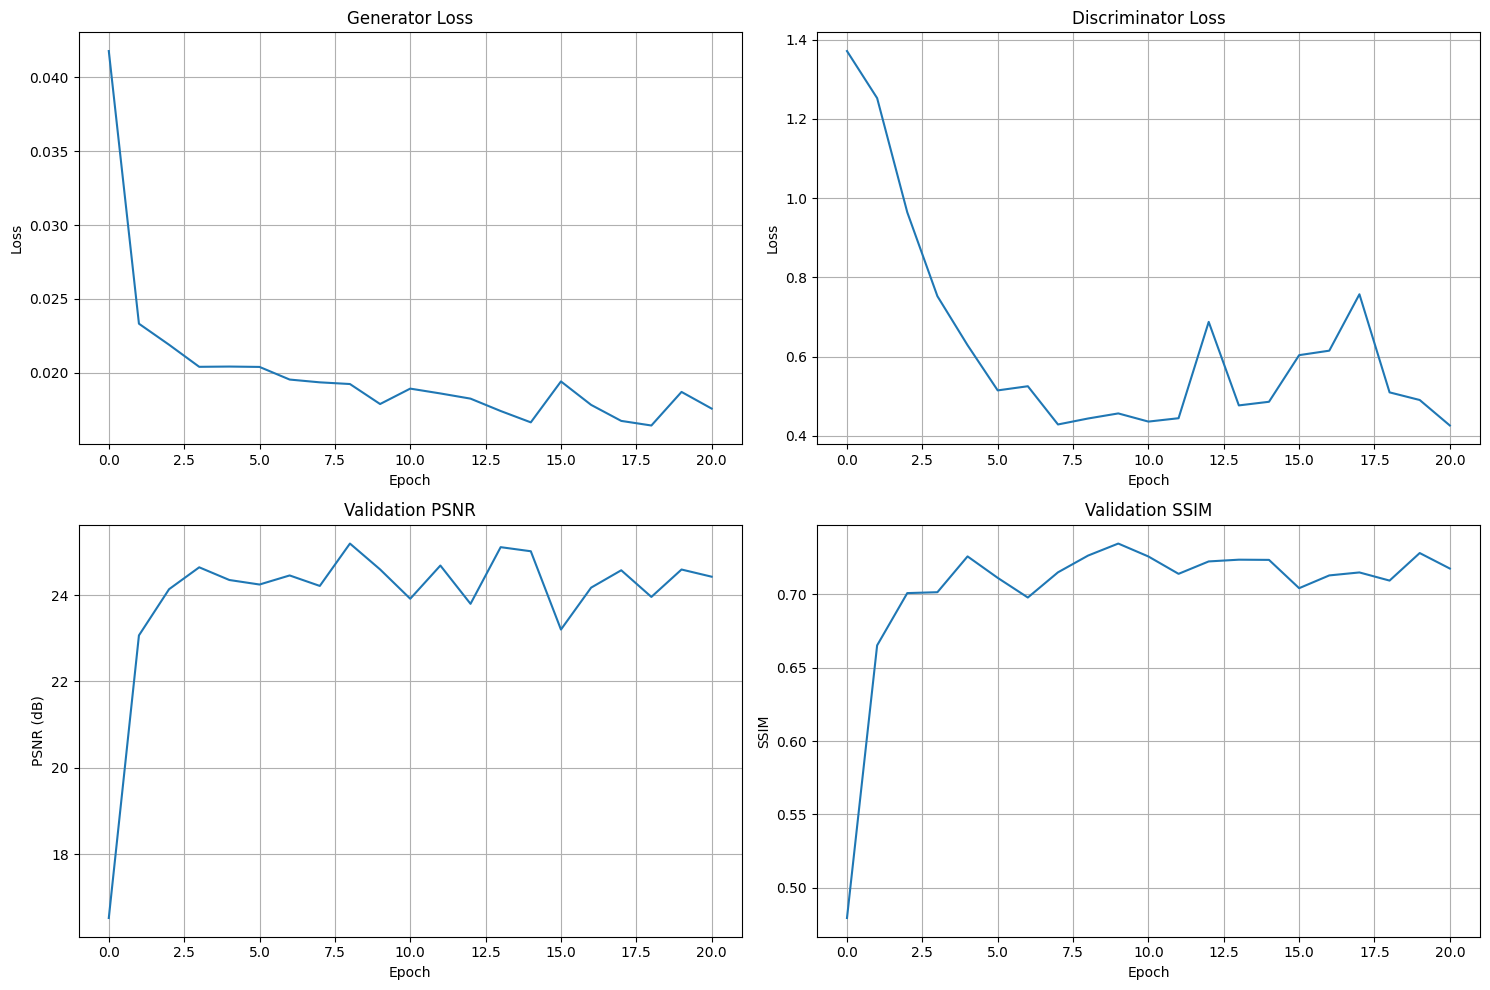

[DEBUG] Loading test data...
[DEBUG] Found 159 NORMAL test images


Processing NORMAL test images: 100%|██████████| 20/20 [00:00<00:00, 41.31it/s]


[DEBUG] Found 428 PNEUMONIA test images


Processing PNEUMONIA test images: 100%|██████████| 20/20 [00:00<00:00, 126.39it/s]

[DEBUG] Dataset initialized with 40 image pairs
[DEBUG] Test loader: 5 batches


[DEBUG] Average PSNR: 24.66 dB
[DEBUG] Average SSIM: 0.7249


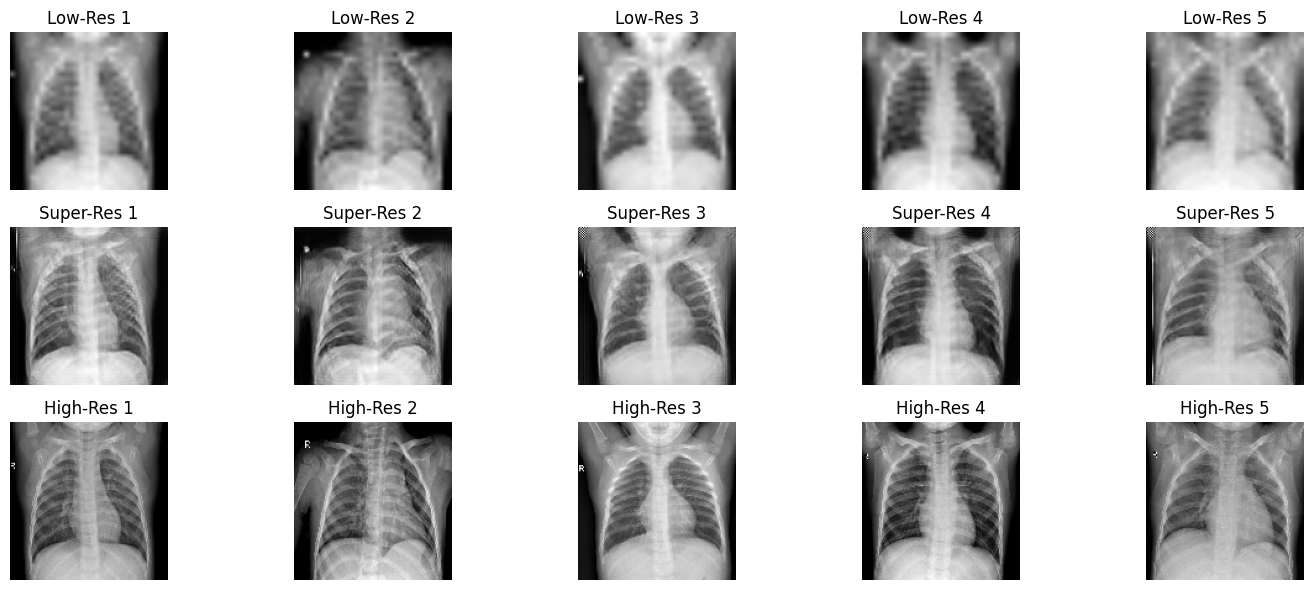

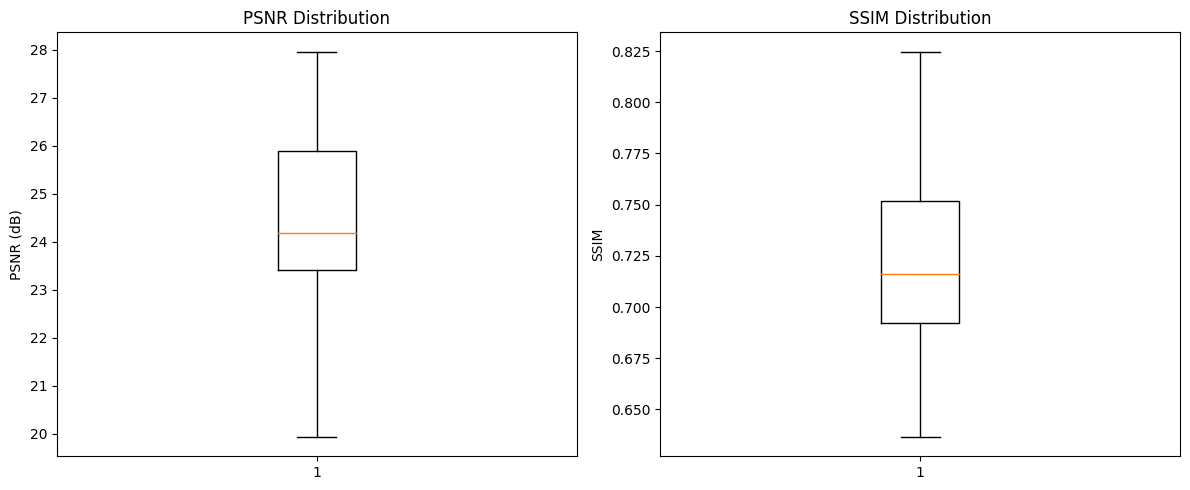

Metrics saved to metrics_results.csv
SRGAN training and evaluation completed successfully!


In [16]:
if __name__ == "__main__":
    main()